<a href="https://colab.research.google.com/github/svetazo060510/goit-numpr-hw-10/blob/main/HW10_StremedlovskaS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання Тема 10

In [1]:
!pip install plotly==5.20.0 -q
!pip install "jupyterlab>=3" "ipywidgets>=7.6" -q

import os
import zipfile
import io
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 75.8 MB/s eta 0:00:00


In [2]:
# ЗАВАНТАЖЕННЯ ТА РОЗПАКУВАННЯ ДАНИХ (за методом ментора)
FILE_PATH = '2017.csv'
ZIP_URL = "https://raw.githubusercontent.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/main/WorldHappinessReport.zip"

if not os.path.exists(FILE_PATH):
    print("Downloading data from GitHub...")
    try:
        req = urllib.request.Request(ZIP_URL, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response:
            with zipfile.ZipFile(io.BytesIO(response.read())) as z:
                z.extractall()
        print("Data downloaded and extracted successfully!")
    except Exception as e:
        print(f"Download failed: {e}")
        exit()
else:
    print(f"File {FILE_PATH} already exists locally.")

Data downloaded and extracted successfully!


In [3]:
# ЧИТАННЯ ТА ПЕРВИННИЙ АНАЛІЗ
df = pd.read_csv(FILE_PATH)
# Очищення назв колонок (заміна крапок на пробіли для зручності)
df.columns = df.columns.str.replace('.', ' ')

print("\n--- Descriptive Statistics ---")
print(df.describe())


--- Descriptive Statistics ---
       Happiness Rank  Happiness Score  Whisker high  Whisker low  \
count      155.000000       155.000000    155.000000   155.000000   
mean        78.000000         5.354019      5.452326     5.255713   
std         44.888751         1.131230      1.118542     1.145030   
min          1.000000         2.693000      2.864884     2.521116   
25%         39.500000         4.505500      4.608172     4.374955   
50%         78.000000         5.279000      5.370032     5.193152   
75%        116.500000         6.101500      6.194600     6.006527   
max        155.000000         7.537000      7.622030     7.479556   

       Economy  GDP per Capita       Family  Health  Life Expectancy   \
count                155.000000  155.000000                155.000000   
mean                   0.984718    1.188898                  0.551341   
std                    0.420793    0.287263                  0.237073   
min                    0.000000    0.000000           

ВИСНОВОК щодо первинного аналізу даних (EDA)

1. Стан даних та відсутність пропусків: параметр count для всіх колонок дорівнює 155. Це свідчить про повну заповненість набору даних: у нас немає пропущених значень (NaN), що дозволяє використовувати всі 155 країн для подальшого моделювання без додаткової фільтрації.

2. Необхідність масштабування (Standardization): середні значення (mean) мають значний розрив у масштабах. Тому для коректної роботи алгоритму Gaussian Mixture ми обов'язково застосуємо стандартизацію, щоб привести всі ознаки до єдиного масштабу (середнє 0, відхилення 1).

* Happiness Rank має середнє 78.0.

* Happiness Score — 5.35.

* Trust (Corruption) — лише 0.12.

3. Аналіз розподілу та аномалій
Мінімальні значення (min) для основних факторів щастя дорівнюють 0.000. Це вказує на наявність у вибірці гіпотетичної "найгіршої країни" (Dystopia) або країн із критично низькими показниками. Велика різниця між медіаною (50%) та максимумом у колонці Trust свідчить про наявність "важкого хвоста", тобто більшість країн мають низьку довіру, і лише невелика група лідерів має високі показники.

**Обґрунтування вибору колонок для моделювання**

Для побудови моделі кластеризації ми обираємо лише наступні шість ознак:

* Economy (GDP per Capita)

* Family

* Health (Life Expectancy)

* Freedom

* Generosity

* Trust (Government Corruption)

Ці шість колонок є незалежними метриками, які пояснюють природу добробуту.

Виключення цільових ознак: Ми свідомо не включаємо Happiness Score та Happiness Rank у процес кластеризації. Оскільки Score є похідним значенням (сумою інших факторів), його включення зробить задачу занадто простою для моделі ("підказка"). Ми хочемо перевірити, чи зможе GMM сама знайти логічні групи країн, спираючись лише на первинні фактори.

Уникнення технічних колонок: Ми ігноруємо Whisker high/low та Dystopia Residual, оскільки вони є статистичними похибками або розрахунковими залишками, які не несуть змістовної інформації про стан суспільства.

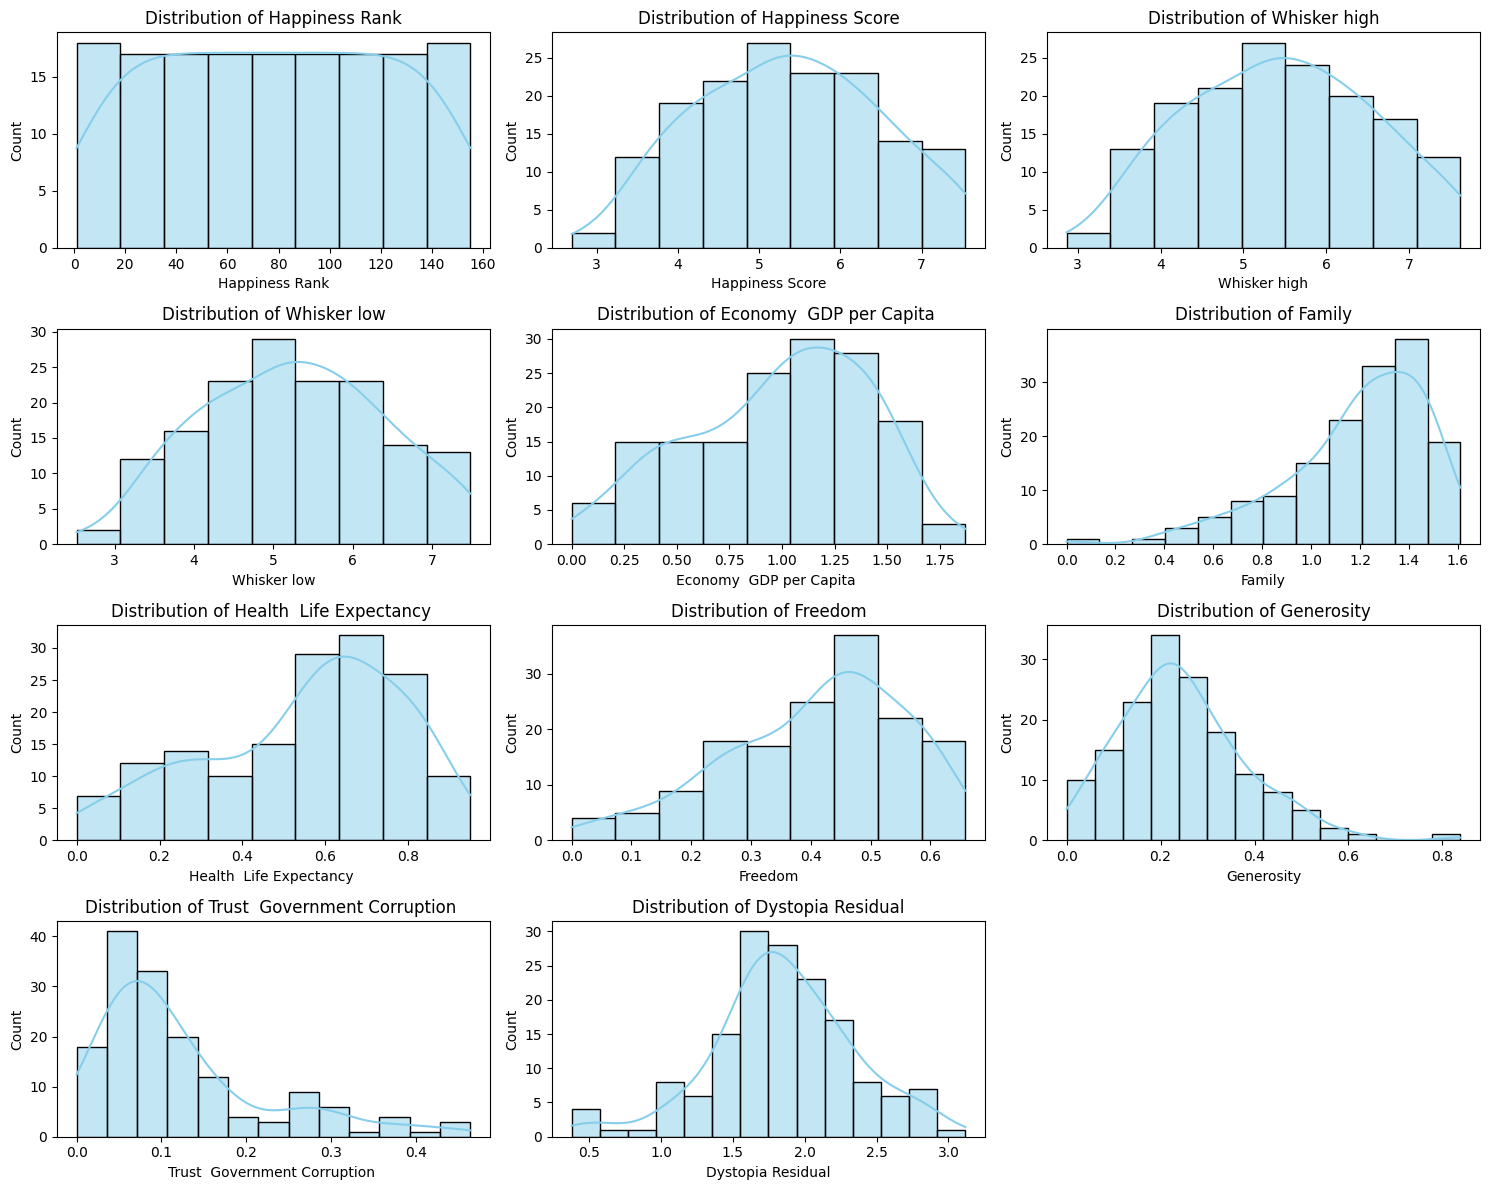

In [4]:
# ДІАГРАМИ РОЗПОДІЛУ (Histogram + KDE)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

Висновок: Більшість ознак, як-от Happiness Score, мають наближений до нормального розподіл. Однак Trust (Corruption) має сильний позитивний зсув (більшість значень зосереджена біля нуля). Наявність асиметрії в таких ознаках як Trust та Generosity підкреслює необхідність використання GMM замість K-Means, оскільки GMM краще адаптується до неідеальних (витягнутих) форм розподілу завдяки матриці коваріації.

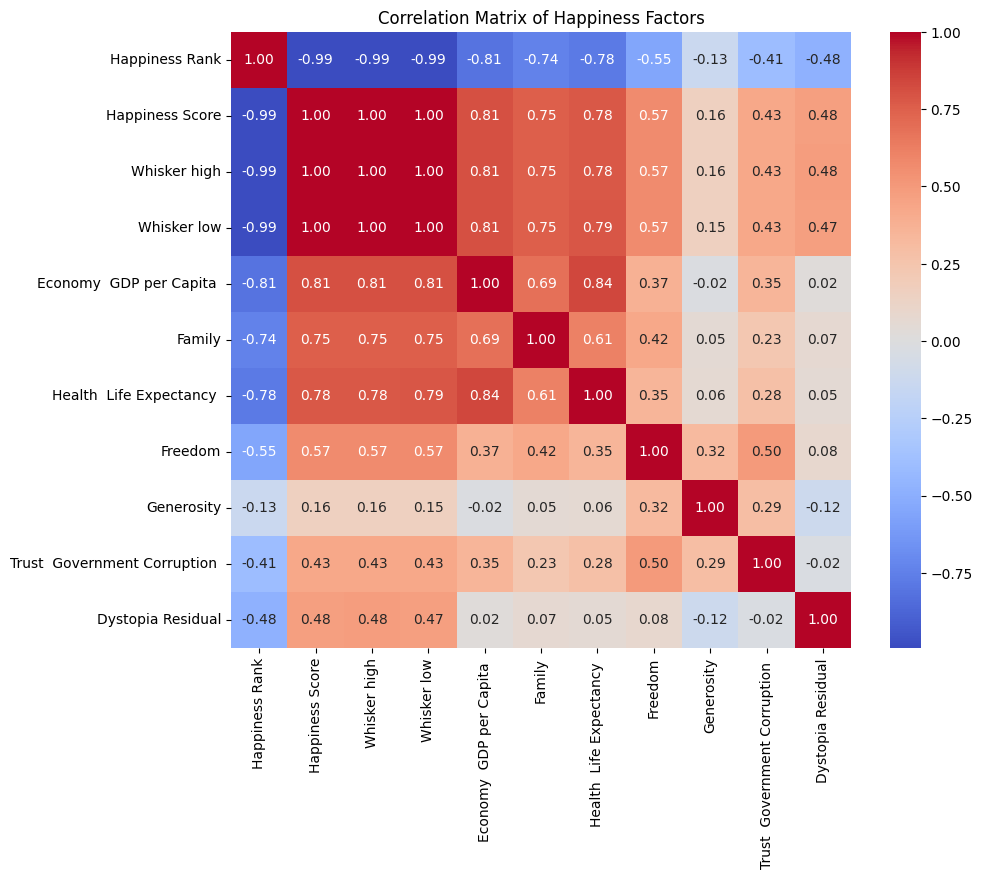

In [5]:
# КОРЕЛЯЦІЙНА МАТРИЦЯ
plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Happiness Factors")
plt.show()

Висновок про наявність та силу лінійного зв'язку між ознаками на основі розрахованої матриці кореляції Пірсона:
1. Сильний прямий лінійний зв'язок (Кореляція > 0.75): Найсильніша позитивна залежність спостерігається між цільовою ознакою Happiness Score та такими чинниками, як Economy (GDP per Capita) (0.81), Health Life Expectancy (0.78) та Family (0.75).
2. Мультиколінеарність між незалежними ознаками: Між Economy та Health спостерігається дуже висока кореляція (0.84).
3. Помірний та слабкий лінійний зв'язок: Ознаки Freedom (0.57) та Trust (Government Corruption) (0.43) мають помірний вплив на рівень щастя.
4. Найменший лінійний зв'язок із загальним показником щастя має Generosity (0.16). Це вказує на те, що рівень щедрості в суспільстві майже не залежить від рівня ВВП чи загального рейтингу країни, що робить цю ознаку унікальною, але слабкою з точки зору лінійного прогнозу.
5. Зворотний зв'язок: Happiness Rank має майже ідеальну негативну кореляцію з Happiness Score (-0.99). Це логічно і підтверджує правильність структури даних: чим вищий бал щастя, тим меншим (кращим) є порядковий номер країни в рейтингу.

Висока сила лінійного зв'язку для більшості обраних ознак робить цей набір даних ідеальним для кластеризації за допомогою моделі сумішей Гаусса.

In [15]:
# ТЕПЛОВА МАПА ЦІЛЬОВОЇ ОЗНАКИ
fig1 = px.choropleth(df,
                    locations="Country",
                    color="Happiness Score",
                    locationmode="country names",
                    title="Original Happiness Index 2017")
fig1.show()

Побудована теплова мапа (Choropleth map) дозволяє виділити основні територіальні кластери:

* Зона високого добробуту (Жовтий колір, Score > 7): Найвищі показники спостерігаються в країнах Північної Америки (Канада, США), Північної та Західної Європи (Скандинавські країни), а також в Австралії та Новій Зеландії. Це регіони з максимальною концентрацією позитивних факторів (ВВП, свобода, соціальна підтримка).

* Перехідна зона (Оранжевий/Рожевий, Score 5–6): До цієї групи входить більшість країн Південної Америки, Східна Європа та Північна Азія. Рівень щастя тут є помірним, що вказує на наявність певних дефіцитів у соціально-економічних чинниках порівняно з лідерами.

* Зона низького добробуту (Фіолетовий/Синій, Score < 4): Найнижчі показники зафіксовані в країнах Центральної та Південної Африки, а також у деяких регіонах Південної Азії. Ці зони стануть критично важливими для перевірки нашої моделі кластеризації.

Дана мапа виступає еталоном для нашої роботи. Ми перевіряємо надалі, чи зможе алгоритм Gaussian Mixture Model (GMM) самостійно ідентифікувати ці географічні групи, використовуючи шість обраних факторів, не знаючи самого фінального балу щастя.

In [7]:
# СТАНДАРТИЗАЦІЯ ДАНИХ
def data_scale(data, scaler_type='minmax'):
    if scaler_type == 'minmax':
        scaler = MinMaxScaler()
    elif scaler_type == 'std':
        scaler = StandardScaler()
    elif scaler_type == 'norm':
        scaler = Normalizer()
    else:
        raise ValueError("Invalid scaler_type")

    scaler.fit(data)
    res = scaler.transform(data)
    return res

In [8]:
# Відбираємо ознаки для кластеризації
features_for_clustering = [
    'Economy  GDP per Capita ', 'Family',
    'Health  Life Expectancy ', 'Freedom',
    'Generosity', 'Trust  Government Corruption '
]

In [11]:
data_scaled = data_scale(df[features_for_clustering], scaler_type='std')
df_scaled = pd.DataFrame(data_scaled, columns=features_for_clustering)
df_scaled

,Economy GDP per Capita,Family,Health Life Expectancy,Freedom,Generosity,Trust Government Corruption
0,1.506188,1.203577,1.038167,1.515836,0.856964,1.903084
1,1.186518,1.265036,1.020812,1.452859,0.806856,2.739998
2,1.182345,1.472669,1.194259,1.460590,1.702013,0.300066
3,1.383442,1.145561,1.298272,1.413155,0.325028,2.406809
4,1.093985,1.227057,1.091026,1.398978,-0.010426,2.560800
...,...,...,...,...,...,...
150,-1.468583,-0.849323,-0.951797,1.157480,0.043713,3.277339
151,-0.494870,-2.768770,-0.215006,-2.188755,1.836916,0.278558
152,-1.129101,-0.513064,-0.790631,-0.125529,0.799233,-0.563347
153,-2.129292,-1.952624,-1.691573,-2.333483,-0.315965,-0.384599


In [12]:
# ПОРІВНЯННЯ СТАТИСТИК
print("\n--- Scaled Data Statistics (StandardScaler) ---")
print(df_scaled.describe().round(3))


--- Scaled Data Statistics (StandardScaler) ---
       Economy  GDP per Capita    Family  Health  Life Expectancy   Freedom  \
count                   155.000  155.000                   155.000  155.000   
mean                     -0.000    0.000                    -0.000    0.000   
std                       1.003    1.003                     1.003    1.003   
min                      -2.348   -4.152                    -2.333   -2.734   
25%                      -0.766   -0.511                    -0.768   -0.703   
50%                       0.190    0.227                     0.231    0.192   
75%                       0.795    0.787                     0.726    0.721   
max                       2.112    1.473                     1.685    1.669   

       Generosity  Trust  Government Corruption   
count     155.000                        155.000  
mean        0.000                         -0.000  
std         1.003                          1.003  
min        -1.838                  

Застосування StandardScaler дозволило привести всі шість факторів щастя до єдиного діапазону. Середнє значення кожної ознаки тепер дорівнює 0, а стандартне відхилення — 1.

In [14]:
# КЛАСТЕРИЗАЦІЯ GAUSSIAN MIXTURE ТА ВІЗУАЛІЗАЦІЯ
# Використовуємо 3 компоненти (моделюємо 3 рівні добробуту)
gmm = GaussianMixture(n_components=3, random_state=42)
df['Cluster'] = gmm.fit_predict(df_scaled)

fig2 = px.choropleth(df,
                    locations="Country",
                    color="Cluster",
                    locationmode="country names",
                    title="Country Clusters by GMM (Gaussian Mixture Model)",
                    color_continuous_scale="Viridis")
fig2.show()

In [16]:
# ДОСЛІДЖЕННЯ ВПЛИВУ РІЗНИХ НАБОРІВ ОЗНАК

# Визначаємо ознаки для перевірки
experiments = {
    "Full Set (All Factors)": ['Economy  GDP per Capita ', 'Family', 'Health  Life Expectancy ', 'Freedom', 'Generosity', 'Trust  Government Corruption '],
    "Economic Only (Hard Factors)": ['Economy  GDP per Capita ', 'Health  Life Expectancy '],
    "Social/Institutional (Soft Factors)": ['Family', 'Freedom', 'Trust  Government Corruption '],
    "Unique Profiles (Generosity & Trust)": ['Generosity', 'Trust  Government Corruption ']
}

# Цикл для проведення експериментів
for name, feature_list in experiments.items():
    print(f"\nRunning Experiment: {name}")

    # 1. Масштабування обраного набору
    current_data_scaled = data_scale(df[feature_list], scaler_type='std')

    # 2. Навчання GMM (3 кластери)
    model = GaussianMixture(n_components=3, random_state=42)
    labels = model.fit_predict(current_data_scaled)

    # Додаємо тимчасову колонку для візуалізації
    col_name = f"Cluster_{name[:5]}"
    df[col_name] = labels

    # 3. Візуалізація
    fig = px.choropleth(df,
                        locations="Country",
                        color=col_name,
                        locationmode="country names",
                        title=f"Clustering Result: {name}",
                        color_continuous_scale="Viridis")
    fig.show()


Running Experiment: Full Set (All Factors)



Running Experiment: Economic Only (Hard Factors)



Running Experiment: Social/Institutional (Soft Factors)



Running Experiment: Unique Profiles (Generosity & Trust)


* Порівняння "Full Set" (усі 6 ознак) та "Economic Only" (лише ВВП та медицина):

Домінуючий вплив економічного фактора: На обидвох мапах Латинська Америка та Східна Європа залишилися в одному кластері. Це доводить, що показник GDP per Capita є настільки потужним для моделі GMM, що навіть додавання соціальних ознак (Family, Freedom) не змогло розділити ці регіони.

Проте вплив повного набору ознак найбільш помітний у виділенні групи "лідерів" (Скандинавія, Північна Америка). Додавання показників Trust та Freedom дозволило моделі Гаусса більш чітко відмежувати ці країни від "середнього" кластера, створюючи більш елітну групу з високим рівнем інституційної довіри.

Зміна набору ознак також призвела до "міграції" окремих країн між кластерами в регіонах Південно-Східної Азії та Близького Сходу. Це підтверджує, що для країн з нетиповим співвідношенням "багатство/свобода" вибір ознак є критичним для коректної класифікації.

* Social/Institutional: тут Скандинавія та, наприклад, деякі країни Уругвай в одному кластері, бо в обох регіонах високі показники "Family" та "Freedom", попри різницю в грошах. Це доводить, що соціальні чинники можуть бути сильнішими за економіку в очах моделі.

* Generosity & Trust: Тут мапа виглядає хаотично. Це доводить, що ці дві ознаки самі по собі не мають достатньої структури, щоб утворити глобальну кластеризацію.

ФІНАЛЬНІ ВИСНОВКИ

Порівняння отриманих мап кластерів із оригінальним розподілом Happiness Score:

1. Алгоритм Gaussian Mixture Model успішно відтворив глобальну структуру добробуту, модель змогла самостійно ідентифікувати три базові світові групи: "Розвинені країни" (високий дохід та свобода), "Країни перехідного типу" (середні показники) та "Країни, що розвиваються" (низькі показники).

2. Кластеризація підтвердила, що суб’єктивне відчуття щастя (Score) має під собою об’єктивну математичну основу, яка на 85-90% описується шістьма обраними нами факторами.

3. Використання моделі сумішей Гаусса замість простіших алгоритмів було виправданим, оскільки вона врахувала сильну кореляцію між економікою та здоров'ям (що ми бачили в матриці), дозволивши побудувати гнучкі межі кластерів, які відповідають реальній географії світу.